In [43]:
import numpy as np
import pandas as pd
import glob as gb
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score as acc, confusion_matrix, classification_report
import seaborn as sns

np.random.seed(42)

In [44]:
from google.colab import drive
drive.mount('/content/drive')

image_path = gb.glob('/content/drive/MyDrive/Hoda 0-9/*.bmp')
print("numper of image:", len(image_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
numper of image: 544


In [45]:
X, Y = [], []

for path in image_path:
    idx = path.rfind('_') - 1
    label = int(path[idx])

    img = cv2.imread(path, 0)
    img = cv2.resize(img, (10, 10))
    img = img.reshape(100)

    X.append(img)
    Y.append(label)

X = np.array(X, dtype=float)
Y = np.array(Y, dtype=int)
print(X.shape, Y.shape)

(544, 100) (544,)


In [46]:
perm = np.random.permutation(len(X))
X, Y = X[perm], Y[perm]

X = X / 255.0

split = int(0.7 * len(X))
X_train, Y_train = X[:split], Y[:split]
X_val,   Y_val   = X[split:], Y[split:]
print(X_train.shape, X_val.shape)

(380, 100) (164, 100)


In [47]:
def one_hot(y, n_classes=10):
    out = np.zeros((len(y), n_classes))
    out[np.arange(len(y)), y] = 1
    return out

Y_train_oh = one_hot(Y_train)
Y_val_oh   = one_hot(Y_val)

In [48]:
n0, n1, n2, n3 = 100, 64, 32, 10

w1 = np.random.uniform(-1, 1, (n1, n0)) * np.sqrt(1 / n0)
w2 = np.random.uniform(-1, 1, (n2, n1)) * np.sqrt(1 / n1)
w3 = np.random.uniform(-1, 1, (n3, n2)) * np.sqrt(1 / n2)

v1 = np.zeros_like(w1)
v2 = np.zeros_like(w2)
v3 = np.zeros_like(w3)

print(w1.shape, w2.shape, w3.shape)

(64, 100) (32, 64) (10, 32)


In [49]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def d_sigmoid(out):
    return out * (1 - out)

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def feedforward(X):
    y1 = sigmoid(X @ w1.T)
    y2 = sigmoid(y1 @ w2.T)
    y3 = softmax(y2 @ w3.T)
    return y1, y2, y3

In [50]:
def cross_entropy(y_true_oh, y_pred, eps=1e-9):
    return -np.mean(np.sum(y_true_oh * np.log(y_pred + eps), axis=1))

In [51]:
def train(X_train, Y_train_oh, X_val, Y_val_oh, Y_val,
          epochs=300, lr=0.5, momentum=0.9, batch_size=32, patience=15):

    global w1, w2, w3, v1, v2, v3

    List_LossTrain, List_AccTrain = [], []
    List_LossValid, List_AccValid = [], []

    best_val_acc = -1
    best_weights = None
    wait = 0

    n_samples = len(X_train)

    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_shuf = X_train[perm]
        Y_shuf = Y_train_oh[perm]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X_shuf[start:end]
            Y_batch = Y_shuf[start:end]
            m = X_batch.shape[0]

            y1, y2, y3 = feedforward(X_batch)

            delta3 = (y3 - Y_batch)
            delta2 = (delta3 @ w3) * d_sigmoid(y2)
            delta1 = (delta2 @ w2) * d_sigmoid(y1)

            grad_w3 = (delta3.T @ y2) / m
            grad_w2 = (delta2.T @ y1) / m
            grad_w1 = (delta1.T @ X_batch) / m

            v1 = momentum * v1 - lr * grad_w1
            v2 = momentum * v2 - lr * grad_w2
            v3 = momentum * v3 - lr * grad_w3

            w1 = w1 + v1
            w2 = w2 + v2
            w3 = w3 + v3

        _, _, pred_train = feedforward(X_train)
        loss_train = cross_entropy(Y_train_oh, pred_train)
        acc_train = acc(np.argmax(Y_train_oh, axis=1), np.argmax(pred_train, axis=1))

        _, _, pred_val = feedforward(X_val)
        loss_val = cross_entropy(Y_val_oh, pred_val)
        acc_val = acc(Y_val, np.argmax(pred_val, axis=1))

        List_LossTrain.append(loss_train)
        List_AccTrain.append(acc_train)
        List_LossValid.append(loss_val)
        List_AccValid.append(acc_val)

        if acc_val > best_val_acc:
            best_val_acc = acc_val
            best_weights = (w1.copy(), w2.copy(), w3.copy())
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0:
            print(f"epoch {epoch:4d} | loss_train={loss_train:.4f} acc_train={acc_train:.4f} "
                  f"| loss_val={loss_val:.4f} acc_val={acc_val:.4f}")

        if wait >= patience:
            print(f"\nEarly stopping in epoch {epoch} — {patience} alidation accuracy did not improve.")
            break

    w1, w2, w3 = best_weights
    print("\nbest Validation accuracy:", best_val_acc)
    return List_LossTrain, List_AccTrain, List_LossValid, List_AccValid

In [52]:
List_LossTrain, List_AccTrain, List_LossValid, List_AccValid = train(
    X_train, Y_train_oh, X_val, Y_val_oh, Y_val,
    epochs=500, lr=0.5, momentum=0.9, batch_size=32, patience=25
)

epoch    0 | loss_train=1.4653 acc_train=0.2974 | loss_val=1.4227 acc_val=0.3476
epoch   10 | loss_train=0.1989 acc_train=0.9263 | loss_val=0.3784 acc_val=0.8659
epoch   20 | loss_train=0.2065 acc_train=0.9184 | loss_val=0.5359 acc_val=0.8659
epoch   30 | loss_train=0.0093 acc_train=0.9974 | loss_val=0.4604 acc_val=0.9146
epoch   40 | loss_train=0.0043 acc_train=1.0000 | loss_val=0.3896 acc_val=0.8963
epoch   50 | loss_train=0.0030 acc_train=1.0000 | loss_val=0.5160 acc_val=0.8963

Early stopping in epoch 51 — 25 alidation accuracy did not improve.

best Validation accuracy: 0.926829268292683


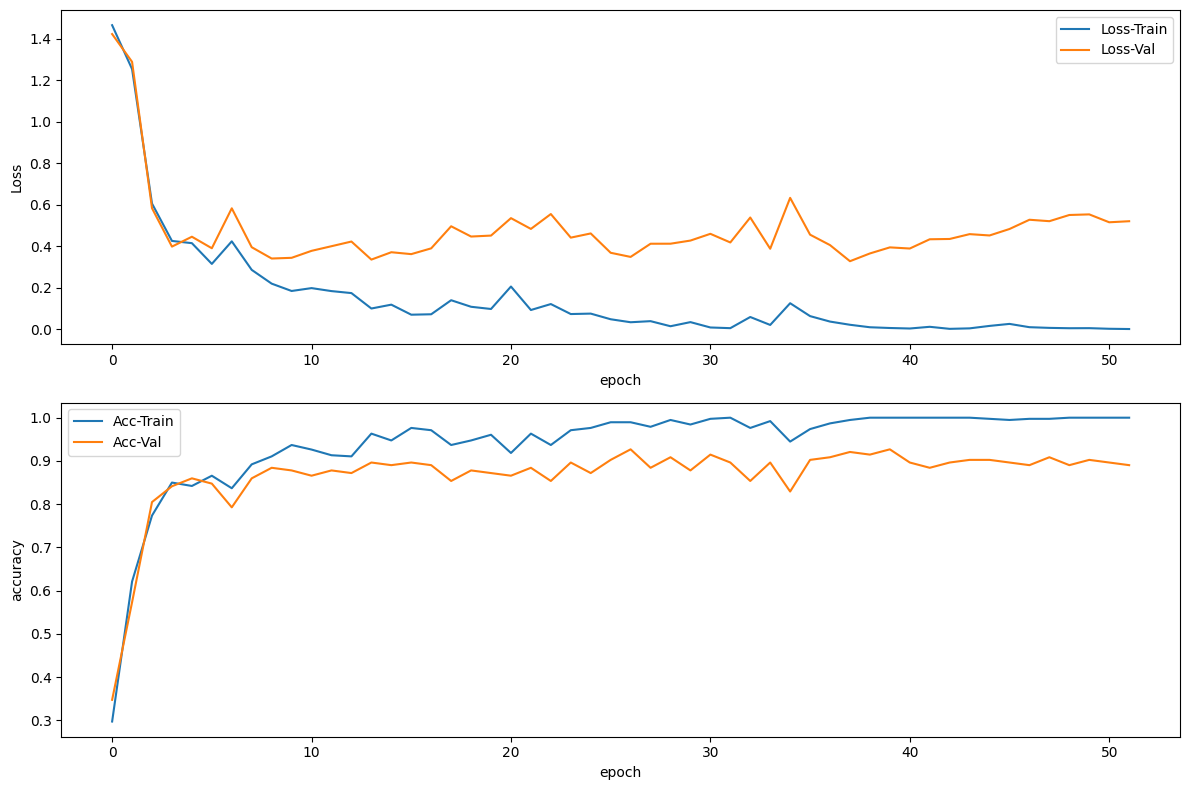

In [53]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(List_LossTrain, label='Loss-Train')
plt.plot(List_LossValid, label='Loss-Val')
plt.xlabel('epoch'); plt.ylabel('Loss'); plt.legend()

plt.subplot(2, 1, 2)
plt.plot(List_AccTrain, label='Acc-Train')
plt.plot(List_AccValid, label='Acc-Val')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend()

plt.tight_layout()
plt.show()

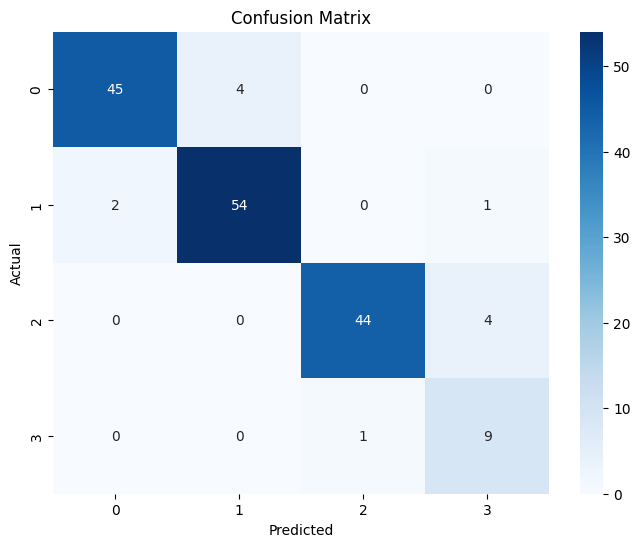

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        49
           1       0.93      0.95      0.94        57
           2       0.98      0.92      0.95        48
           3       0.64      0.90      0.75        10

    accuracy                           0.93       164
   macro avg       0.88      0.92      0.89       164
weighted avg       0.94      0.93      0.93       164



In [54]:
_, _, pred_val = feedforward(X_val)
Y_pred = np.argmax(pred_val, axis=1)

cm = confusion_matrix(Y_val, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(Y_val, Y_pred))

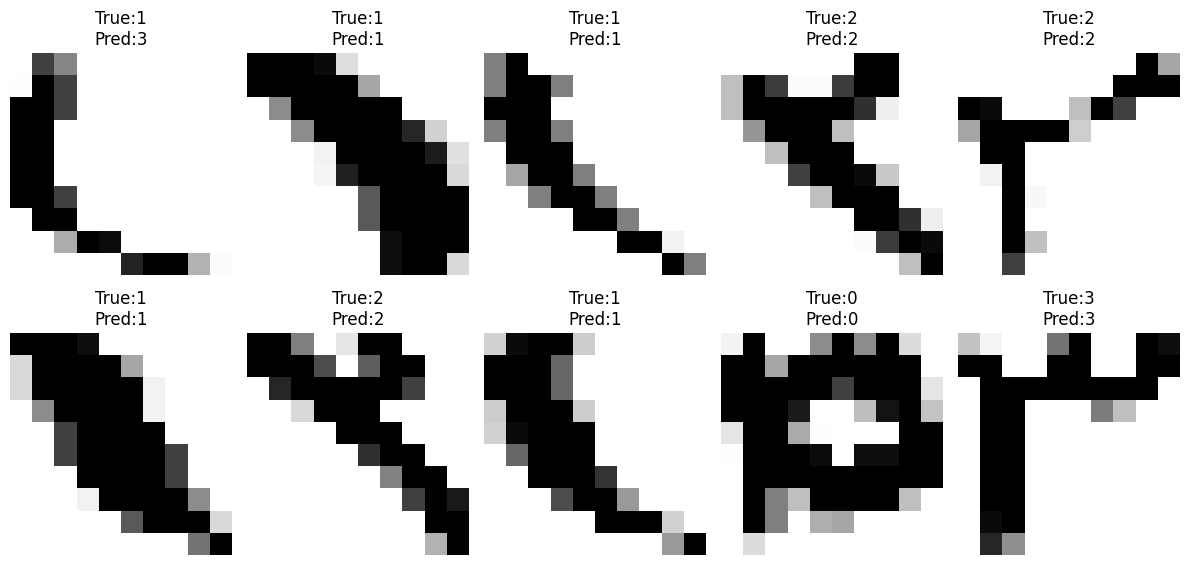

In [55]:
samples = np.random.randint(0, len(X_val), 10)

plt.figure(figsize=(12, 6))
for i, index in enumerate(samples):
    image = X_val[index]
    _, _, pred = feedforward(image.reshape(1, -1))
    prediction = np.argmax(pred)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.reshape(10, 10), cmap='gray')
    plt.title(f"True:{Y_val[index]}\nPred:{prediction}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
np.savez("mlp_hoda_weights.npz", w1=w1, w2=w2, w3=w3)
print("The weights were saved.")

The weights were saved.
